# Majitar Restaurant Reviews — Sentiment Analysis
> Google Reviews scraped via Apify | 197 reviews | 10 restaurants

**Project structure:**
- Text cleaning & preprocessing
- TextBlob NLP + star-rating hybrid sentiment
- Aspect-based sentiment (food items)
- Visualisations: pie chart, stacked bars, word cloud
- Key insights for academic report


## Install required libraries


In [1]:
# Run this cell once, then restart the kernel if needed.
# !pip install textblob wordcloud matplotlib seaborn pandas nltk
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports & NLTK downloads


In [2]:
import json
import re
import warnings
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from textblob import TextBlob
import nltk

# Download required NLTK resources quietly
for resource in ["punkt", "stopwords", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords

# Suppress all warnings for clean notebook output
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


## Load JSON dataset


In [3]:
# ── Change this path if your file is elsewhere ──
JSON_PATH = "majitar_reviews.json"   # <-- update if needed

with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"📦 Total records loaded : {len(raw_data)}")
print(f"📋 Keys in each record  : {list(raw_data[0].keys())[:8]} …")


📦 Total records loaded : 197
📋 Keys in each record  : ['title', 'reviewerId', 'reviewerUrl', 'name', 'reviewerNumberOfReviews', 'isLocalGuide', 'reviewerPhotoUrl', 'text'] …


## Build a clean DataFrame (safe column extraction)


In [4]:
def safe_get(record: dict, key: str, default=None):
    """Return record[key] if it exists and is not None; else default."""
    return record.get(key) or default


rows = []
for rec in raw_data:
    # Use 'textTranslated' when the original text is non-English
    text_raw = safe_get(rec, "text", "")
    text_translated = safe_get(rec, "textTranslated", "")
    review_text = text_translated if text_translated else text_raw

    rows.append({
        "restaurant"  : safe_get(rec, "title", "Unknown"),
        "text_raw"    : review_text,
        "stars"       : safe_get(rec, "stars", np.nan),
    })

df_raw = pd.DataFrame(rows)
print(f"\n📊 DataFrame shape : {df_raw.shape}")
print(df_raw.dtypes)
print(df_raw.head(3))



📊 DataFrame shape : (197, 3)
restaurant    object
text_raw      object
stars          int64
dtype: object
     restaurant  \
0  Coffee Break   
1  Coffee Break   
2  Coffee Break   

                                                                                                                  text_raw  \
0  Coffee Break is a great spot for a quick bite with plenty of options. I especially love their panini and the sizzlin...   
1                                                          Good atmosphere with good food but the price is little bit more   
2  The food is really very tasty and the cakes are the best.... The ambience is very comforting and gives a nice vibe.....   

   stars  
0      5  
1      5  
2      5  


## Preprocessing & text cleaning


In [5]:
STOP_WORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """
    Cleans a review string:
      1. Lower-case
      2. Remove URLs, special characters, extra whitespace
      3. Keep only alphabetic tokens (preserves meaningful text for TextBlob)
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)                 # keep only letters
    text = re.sub(r"\s+", " ", text).strip()              # collapse whitespace
    return text


# Work on a copy — never mutate raw data
df = df_raw.copy()
df["text_clean"] = df["text_raw"].apply(clean_text)

# Convert stars to numeric; coerce non-numeric to NaN
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")

# Mark rows that have usable text
df["has_text"] = df["text_clean"].str.strip().ne("")

print(f"\n🔍 Reviews with text   : {df['has_text'].sum()}")
print(f"🔍 Reviews without text: {(~df['has_text']).sum()}")
print(f"\nStars distribution:\n{df['stars'].value_counts().sort_index()}")



🔍 Reviews with text   : 136
🔍 Reviews without text: 61

Stars distribution:
stars
1     10
2      5
3      8
4     28
5    146
Name: count, dtype: int64


## TextBlob sentiment scoring


In [6]:
def get_textblob_polarity(text: str) -> float:
    """Returns TextBlob polarity in [-1, +1]. Returns 0.0 for empty text."""
    if not text:
        return 0.0
    return TextBlob(text).sentiment.polarity


def polarity_to_label(polarity: float) -> str:
    """Map a polarity score to Positive / Neutral / Negative."""
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"


df["polarity_nlp"] = df["text_clean"].apply(get_textblob_polarity)
df["sentiment_nlp"] = df["polarity_nlp"].apply(polarity_to_label)

print("NLP-only sentiment distribution:")
print(df["sentiment_nlp"].value_counts())


NLP-only sentiment distribution:
sentiment_nlp
Positive    127
Neutral      64
Negative      6
Name: count, dtype: int64


## Hybrid sentiment (NLP + star rating)


In [7]:
# Combining text polarity with star rating gives a more accurate label,
# especially for short or ambiguous reviews.

def stars_to_polarity(stars) -> float:
    """Convert a 1–5 star rating to a [-1, +1] polarity equivalent."""
    if pd.isna(stars):
        return np.nan
    return (stars - 3) / 2.0   # 1→-1, 2→-0.5, 3→0, 4→+0.5, 5→+1


def hybrid_sentiment(row) -> str:
    """
    Combine NLP polarity and star-based polarity with equal weight.
    If stars are missing, fall back to NLP sentiment alone.
    """
    nlp_pol = row["polarity_nlp"]
    star_pol = stars_to_polarity(row["stars"])

    if pd.isna(star_pol):
        # No star rating — rely on text alone
        combined = nlp_pol
    else:
        if row["has_text"]:
            # Weighted average: 60% stars (more reliable), 40% NLP
            combined = 0.6 * star_pol + 0.4 * nlp_pol
        else:
            # No text — rely on star rating alone
            combined = star_pol

    return polarity_to_label(combined)


df["sentiment"] = df.apply(hybrid_sentiment, axis=1)

print("\nHybrid sentiment distribution:")
print(df["sentiment"].value_counts())
print("\nSample rows:")
print(df[["restaurant", "text_raw", "stars", "polarity_nlp", "sentiment"]].head(6).to_string(index=False))



Hybrid sentiment distribution:
sentiment
Positive    176
Negative     14
Neutral       7
Name: count, dtype: int64

Sample rows:
  restaurant                                                                                                                                                                                                                                                                                                               text_raw  stars  polarity_nlp sentiment
Coffee Break                                               Coffee Break is a great spot for a quick bite with plenty of options. I especially love their panini and the sizzling brownie with ice cream. The ambience is also excellent and adds to the experience. Highly recommend visiting for brunch and trying their desserts.      5      0.658667  Positive
Coffee Break                                                                                                                                                    

## Aspect-based sentiment: food item extraction


In [8]:
# A curated vocabulary of food items likely to appear in Majitar restaurant reviews.
FOOD_KEYWORDS = [
    # Beverages
    "coffee", "tea", "chai", "juice", "lassi", "shake", "smoothie",
    "beer", "wine", "cocktail", "drinks", "lemonade",
    # Snacks & starters
    "panini", "sandwich", "wrap", "burger", "fries", "chips",
    "momo", "dumpling", "spring roll", "pakora", "samosa",
    # Mains
    "pizza", "pasta", "noodles", "rice", "biryani", "dal", "curry",
    "thali", "roti", "naan", "paratha", "chicken", "mutton", "fish",
    "pork", "beef", "steak", "grilled", "sizzler",
    # Desserts
    "cake", "pastry", "brownie", "ice cream", "sundae", "dessert",
    "chocolate", "pudding", "mousse", "cheesecake", "pancake",
    "waffle", "donut", "cookie",
    # Local / regional
    "thukpa", "gyathuk", "sael roti", "gundruk", "achaar",
    # Generic
    "food", "snack", "meal", "dish", "menu",
]

# Sort by length (descending) so multi-word phrases match before single words
FOOD_KEYWORDS_SORTED = sorted(FOOD_KEYWORDS, key=len, reverse=True)


def extract_food_items(text: str) -> list:
    """Return all food keywords found in a cleaned review (no duplicates)."""
    if not text:
        return []
    found = []
    for food in FOOD_KEYWORDS_SORTED:
        # Use word-boundary match to avoid partial matches
        pattern = r"\b" + re.escape(food) + r"\b"
        if re.search(pattern, text):
            found.append(food)
    return found


df["food_items"] = df["text_clean"].apply(extract_food_items)

# Explode so each (review, food) pair is its own row
df_food = (
    df[df["food_items"].map(len) > 0]
    .copy()
    .explode("food_items")
    .rename(columns={"food_items": "food_item"})
    [["restaurant", "food_item", "sentiment", "polarity_nlp", "stars"]]
    .reset_index(drop=True)
)

print(f"\n🍽️  Food-mention records : {len(df_food)}")
print(f"🍽️  Unique food items    : {df_food['food_item'].nunique()}")
print(df_food["food_item"].value_counts().head(15))



🍽️  Food-mention records : 151
🍽️  Unique food items    : 26
food_item
food       79
chicken    11
coffee     10
lassi       6
biryani     5
cake        4
roti        4
menu        3
meal        3
naan        3
mutton      2
tea         2
dish        2
paratha     2
rice        2
Name: count, dtype: int64


## Food-level sentiment aggregation


In [9]:
# Pivot: count Positive / Neutral / Negative mentions per food item.
food_sentiment_pivot = (
    df_food.groupby(["food_item", "sentiment"])
    .size()
    .unstack(fill_value=0)          # missing categories → 0
    .reindex(columns=["Positive", "Neutral", "Negative"], fill_value=0)
    .reset_index()
)

food_sentiment_pivot["total"]      = food_sentiment_pivot[["Positive", "Neutral", "Negative"]].sum(axis=1)
food_sentiment_pivot["pos_ratio"]  = food_sentiment_pivot["Positive"] / food_sentiment_pivot["total"]
food_sentiment_pivot["neg_ratio"]  = food_sentiment_pivot["Negative"] / food_sentiment_pivot["total"]

# Filter to food items mentioned at least twice
food_filtered = food_sentiment_pivot[food_sentiment_pivot["total"] >= 2].copy()
food_filtered = food_filtered.sort_values("total", ascending=False)

print("\n🥇 Food items by mention count:")
print(food_filtered[["food_item","Positive","Neutral","Negative","total","pos_ratio"]].to_string(index=False))

# Top 5 most-loved & most-criticised foods
top_loved     = food_filtered.nlargest(5, "pos_ratio")
top_criticised = food_filtered.nlargest(5, "neg_ratio")

print("\n🟢 Most POSITIVELY mentioned foods:")
print(top_loved[["food_item","Positive","total","pos_ratio"]].to_string(index=False))

print("\n🔴 Most NEGATIVELY mentioned foods:")
print(top_criticised[["food_item","Negative","total","neg_ratio"]].to_string(index=False))



🥇 Food items by mention count:
food_item  Positive  Neutral  Negative  total  pos_ratio
     food        71        2         6     79   0.898734
  chicken        11        0         0     11   1.000000
   coffee         9        0         1     10   0.900000
    lassi         6        0         0      6   1.000000
  biryani         4        0         1      5   0.800000
     cake         4        0         0      4   1.000000
     roti         4        0         0      4   1.000000
     menu         2        0         1      3   0.666667
     meal         3        0         0      3   1.000000
     naan         3        0         0      3   1.000000
     dish         1        0         1      2   0.500000
   drinks         1        0         1      2   0.500000
   mutton         2        0         0      2   1.000000
  paratha         1        0         1      2   0.500000
    pizza         2        0         0      2   1.000000
     rice         1        0         1      2   0.500000

## Visualisation helper


In [10]:
PALETTE = {"Positive": "#4CAF50", "Neutral": "#FFC107", "Negative": "#F44336"}

def set_chart_style():
    plt.rcParams.update({
        "figure.facecolor" : "#FAFAFA",
        "axes.facecolor"   : "#FAFAFA",
        "axes.spines.top"  : False,
        "axes.spines.right": False,
        "font.family"      : "DejaVu Sans",
    })

set_chart_style()


## Chart 1: Overall Sentiment Distribution (Pie)


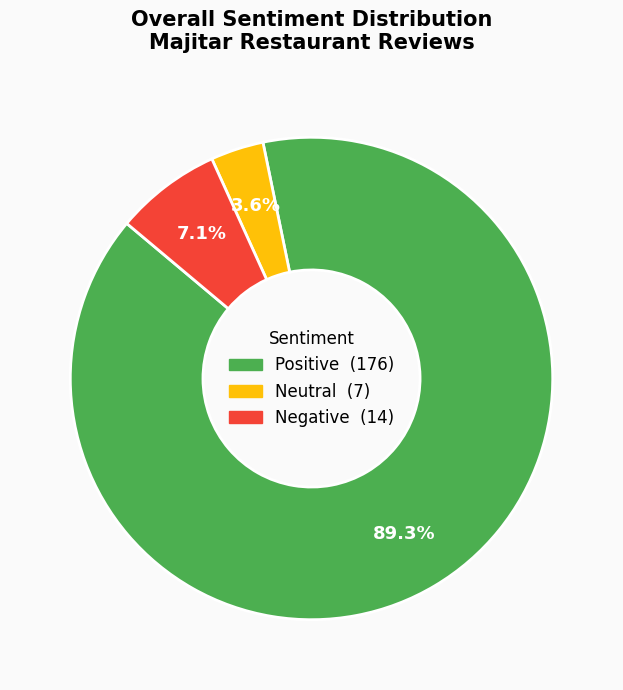

✅ Saved: chart1_sentiment_pie.png


In [11]:
sentiment_counts = df["sentiment"].value_counts()

# Ensure all three categories appear (fill 0 if missing)
for cat in ["Positive", "Neutral", "Negative"]:
    if cat not in sentiment_counts.index:
        sentiment_counts[cat] = 0
sentiment_counts = sentiment_counts.reindex(["Positive", "Neutral", "Negative"])

fig, ax = plt.subplots(figsize=(7, 7))
wedge_props = dict(width=0.55, edgecolor="white", linewidth=2)   # donut style

wedges, texts, autotexts = ax.pie(
    sentiment_counts,
    labels=None,
    autopct="%1.1f%%",
    startangle=140,
    colors=[PALETTE[c] for c in sentiment_counts.index],
    wedgeprops=wedge_props,
    pctdistance=0.75,
    textprops={"fontsize": 13, "fontweight": "bold", "color": "white"},
)

# Legend
legend_patches = [
    mpatches.Patch(color=PALETTE[c], label=f"{c}  ({sentiment_counts[c]})")
    for c in sentiment_counts.index
]
ax.legend(handles=legend_patches, loc="center", fontsize=12,
          frameon=False, title="Sentiment", title_fontsize=12)

ax.set_title("Overall Sentiment Distribution\nMajitar Restaurant Reviews",
             fontsize=15, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("chart1_sentiment_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart1_sentiment_pie.png")


## Chart 2: Sentiment by Restaurant (Stacked Bar)


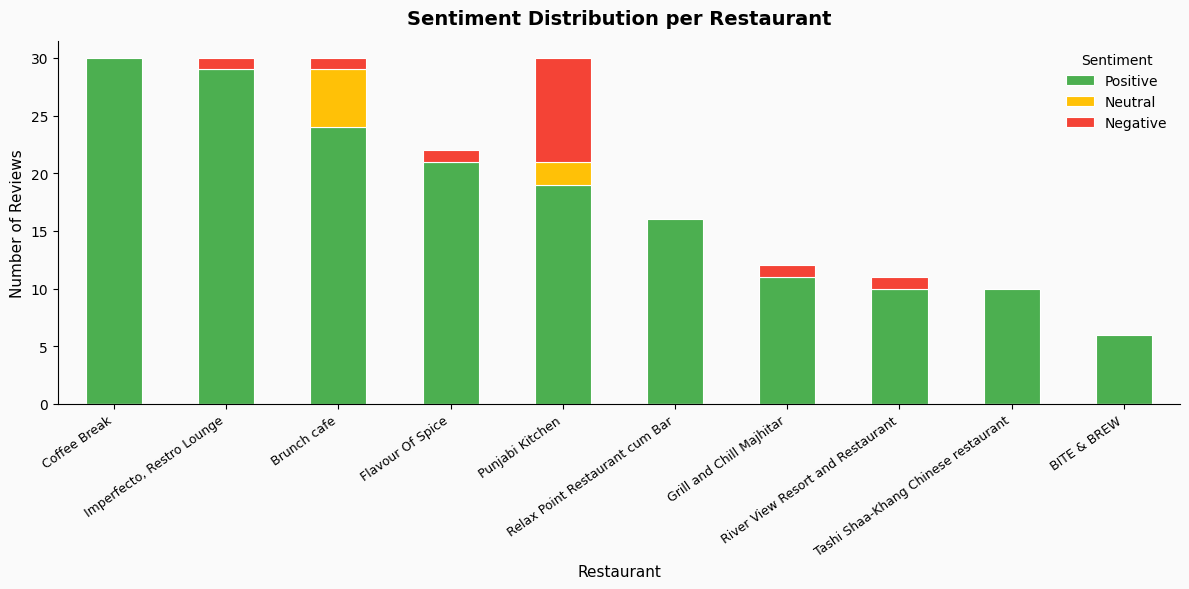

✅ Saved: chart2_restaurant_sentiment.png


In [12]:
rest_sent = (
    df.groupby(["restaurant", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Positive", "Neutral", "Negative"], fill_value=0)
    .sort_values("Positive", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
rest_sent.plot(
    kind="bar", stacked=True, ax=ax,
    color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
    edgecolor="white", linewidth=0.8
)

ax.set_title("Sentiment Distribution per Restaurant", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Restaurant", fontsize=11)
ax.set_ylabel("Number of Reviews", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.legend(title="Sentiment", fontsize=10, title_fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("chart2_restaurant_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart2_restaurant_sentiment.png")


## Chart 3: Food-wise Sentiment (Horizontal Stacked Bar)


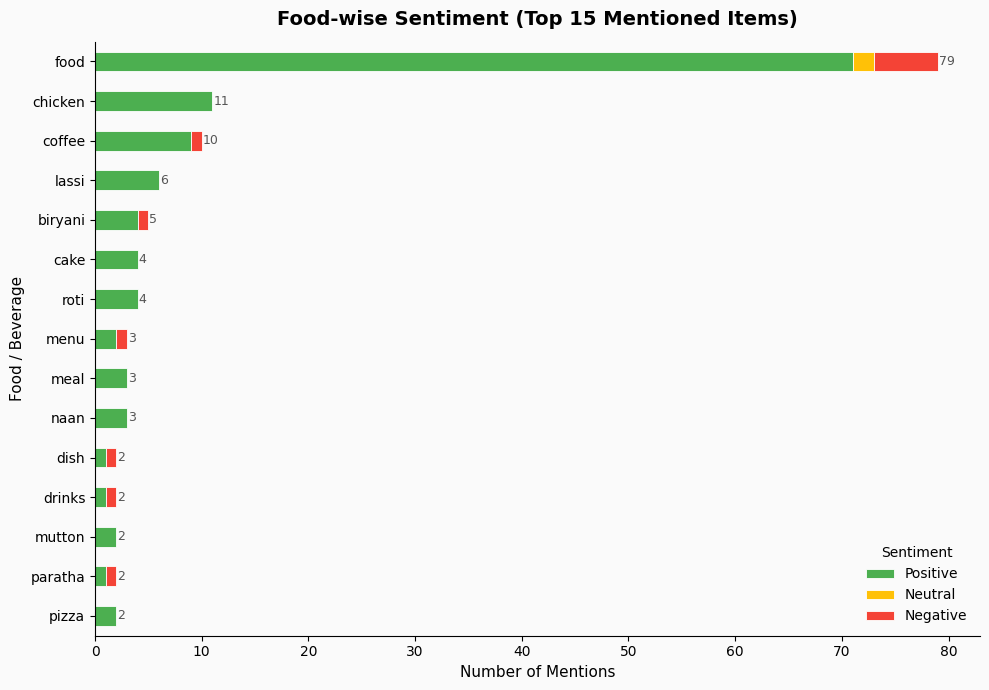

✅ Saved: chart3_food_sentiment.png


In [13]:
# Show the top-N food items by total mentions
TOP_N = 15
plot_data = (
    food_filtered.set_index("food_item")
    [["Positive", "Neutral", "Negative"]]
    .head(TOP_N)
)

fig, ax = plt.subplots(figsize=(10, 7))
plot_data.plot(
    kind="barh", stacked=True, ax=ax,
    color=[PALETTE["Positive"], PALETTE["Neutral"], PALETTE["Negative"]],
    edgecolor="white", linewidth=0.6
)

ax.invert_yaxis()  # most-mentioned at the top
ax.set_title(f"Food-wise Sentiment (Top {TOP_N} Mentioned Items)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Number of Mentions", fontsize=11)
ax.set_ylabel("Food / Beverage", fontsize=11)
ax.legend(title="Sentiment", fontsize=10, title_fontsize=10,
          frameon=False, loc="lower right")

# Annotate total count at the end of each bar
for i, (_, row) in enumerate(plot_data.iterrows()):
    total = int(row.sum())
    ax.text(total + 0.1, i, str(total), va="center", fontsize=9, color="#555")

plt.tight_layout()
plt.savefig("chart3_food_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart3_food_sentiment.png")


## Chart 4: Star Rating Distribution (Bar)


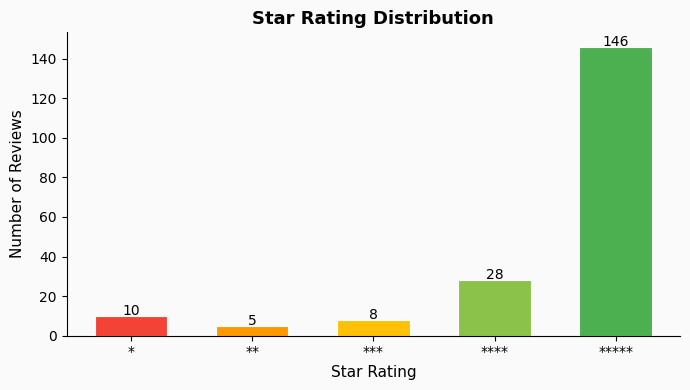

✅ Saved: chart4_star_distribution.png


In [14]:
star_counts = df["stars"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    star_counts.index.astype(int),
    star_counts.values,
    color=["#F44336", "#FF9800", "#FFC107", "#8BC34A", "#4CAF50"],
    edgecolor="white", linewidth=0.8, width=0.6
)

ax.set_title("Star Rating Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Star Rating", fontsize=11)
ax.set_ylabel("Number of Reviews", fontsize=11)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["*", "**", "***", "****", "*****"], fontsize=10)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart4_star_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart4_star_distribution.png")


## Chart 5: Word Cloud (Optional)


In [15]:
try:
    from wordcloud import WordCloud

    # Combine all cleaned review texts
    all_text = " ".join(df.loc[df["has_text"], "text_clean"].tolist())

    # Additional stop words irrelevant to food/service insights
    custom_stop = STOP_WORDS | {
        "place", "go", "visit", "would", "also", "really", "good",
        "great", "nice", "very", "much", "one", "get", "like",
        "little", "bit", "well", "back",
    }

    wc = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap="RdYlGn",
        stopwords=custom_stop,
        max_words=120,
        collocations=True,
        min_font_size=9,
    ).generate(all_text)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Most Frequent Words in Majitar Reviews",
                 fontsize=14, fontweight="bold", pad=12)

    plt.tight_layout()
    plt.savefig("chart5_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart5_wordcloud.png")

except ImportError:
    print("ℹ️  WordCloud not installed. Run:  pip install wordcloud")
# i got error in installing wordcloud so i  enclosed it in try catch block

ℹ️  WordCloud not installed. Run:  pip install wordcloud


## Summary statistics table


In [16]:
summary_df = (
    df.groupby("restaurant")
    .agg(
        total_reviews    = ("sentiment", "count"),
        avg_stars        = ("stars",     lambda x: round(x.mean(), 2)),
        positive_reviews = ("sentiment", lambda x: (x == "Positive").sum()),
        neutral_reviews  = ("sentiment", lambda x: (x == "Neutral").sum()),
        negative_reviews = ("sentiment", lambda x: (x == "Negative").sum()),
        avg_nlp_polarity = ("polarity_nlp", lambda x: round(x.mean(), 3)),
    )
    .reset_index()
    .sort_values("avg_stars", ascending=False)
)

summary_df["positive_%"] = (
    summary_df["positive_reviews"] / summary_df["total_reviews"] * 100
).round(1)

print("\n📋 Restaurant-level Summary:")
print(summary_df.to_string(index=False))



📋 Restaurant-level Summary:
                         restaurant  total_reviews  avg_stars  positive_reviews  neutral_reviews  negative_reviews  avg_nlp_polarity  positive_%
     Relax Point Restaurant cum Bar             16       4.94                16                0                 0             0.194       100.0
                       Coffee Break             30       4.80                30                0                 0             0.538       100.0
Tashi Shaa-Khang Chinese restaurant             10       4.80                10                0                 0             0.416       100.0
          Imperfecto, Restro Lounge             30       4.80                29                0                 1             0.512        96.7
                   Flavour Of Spice             22       4.77                21                0                 1             0.458        95.5
                        BITE & BREW              6       4.67                 6                0     